# Proyecto 1 – Task 2: Neural Network Integration

**CC3045 – Inteligencia Artificial**

## Objetivo
Añadir semántica de terreno al robot de navegación:
- **Task 2.1:** Red Neuronal MLP desde cero con numpy, que clasifica colores RGB a tipos de terreno.
- **Task 2.2:** Integrar la red en A* para que stepCost use inferencia en tiempo real en lugar de un costo fijo.


## Mapeo de costos definido

COLOR_COST_MAP = {  
    'Grey':   1,   # Pavimento/asfalto → ideal para el robot  
    'White':  1,   # Concreto/camino pavimentado → igual que grey  
    'Green':  3,   # Grama → fricción moderada  
    'Brown':  4,   # Tierra/barro → terreno irregular  
    'Yellow': 5,   # Arena → dificulta el movimiento  
    'Orange': 6,   # Arena gruesa / tierra seca → peor que yellow  
    'Pink':   7,   # Terreno desconocido → penalización moderada-alta  
    'Purple': 7,   # Terreno desconocido → penalización moderada-alta  
    'Red':    1,   # Nodo de inicio → costo neutro  
    'Blue':   10,  # Agua → altísimo riesgo, casi intransitable  
    'Black':  99,  # Pared/obstáculo → nunca debe pisarse  
}  

---
## Imports

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
import heapq

np.random.seed(11)

---
# TASK 2.1 – Red Neuronal desde Cero

## Etapa 1 – Preparación del Dataset

In [57]:
# ============================================================
# DATASET LOADER
# ============================================================

def load_dataset(path):
    """
    Carga el dataset RGB desde un CSV.
    Retorna X normalizado [0,1] y etiquetas crudas.
    """
    df = pd.read_csv(path)
    X = df[['R', 'G', 'B']].values.astype(np.float64) / 255.0  # Normalización
    y_raw = df['label'].values
    return X, y_raw


def encode_labels(y_raw):
    """
    Convierte etiquetas de texto a:
    - Índices enteros (y_idx)
    - One-Hot encoding (y_onehot)
    Retorna también los diccionarios de mapeo.
    """
    classes = sorted(list(set(y_raw)))
    label_to_index = {label: i for i, label in enumerate(classes)}
    index_to_label = {i: label for label, i in label_to_index.items()}

    y_idx = np.array([label_to_index[l] for l in y_raw])

    num_classes = len(classes)
    y_onehot = np.zeros((len(y_idx), num_classes))
    y_onehot[np.arange(len(y_idx)), y_idx] = 1

    return y_onehot, y_idx, label_to_index, index_to_label


def train_test_split_manual(X, y_onehot, y_idx, test_size=0.2, seed=42):
    """
    Divide el dataset en 80% entrenamiento y 20% prueba (sin sklearn).
    """
    np.random.seed(seed)
    n = len(X)
    perm = np.random.permutation(n)
    split = int(n * (1 - test_size))
    train_idx, test_idx = perm[:split], perm[split:]
    return (
        X[train_idx], X[test_idx],
        y_onehot[train_idx], y_onehot[test_idx],
        y_idx[train_idx], y_idx[test_idx]
    )


print('Dataset Loader definido')

Dataset Loader definido


In [58]:
# ============================================================
# CARGAR DATASET 
# ============================================================

df = pd.read_csv('final_data_colors.csv')

# Renombrar columnas al formato esperado (minúsculas → mayúsculas)
df = df.rename(columns={'red': 'R', 'green': 'G', 'blue': 'B'})

print(f'Dataset: {len(df)} muestras')
print(df['label'].value_counts())

X_all = df[['R', 'G', 'B']].values.astype(np.float64) / 255.0
y_raw = df['label'].values
y_onehot, y_idx, label_to_index, index_to_label = encode_labels(y_raw)
X_train, X_test, y_oh_train, y_oh_test, y_idx_train, y_idx_test = train_test_split_manual(
    X_all, y_onehot, y_idx
)

print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')
print(f'Clases ({len(label_to_index)}): {label_to_index}')

Dataset: 5052 muestras
label
Green     1457
Blue      1107
Pink       579
Purple     553
Brown      376
Yellow     285
Red        236
Orange     205
Grey       174
Black       51
White       29
Name: count, dtype: int64

Train: 4041 | Test: 1011
Clases (11): {'Black': 0, 'Blue': 1, 'Brown': 2, 'Green': 3, 'Grey': 4, 'Orange': 5, 'Pink': 6, 'Purple': 7, 'Red': 8, 'White': 9, 'Yellow': 10}


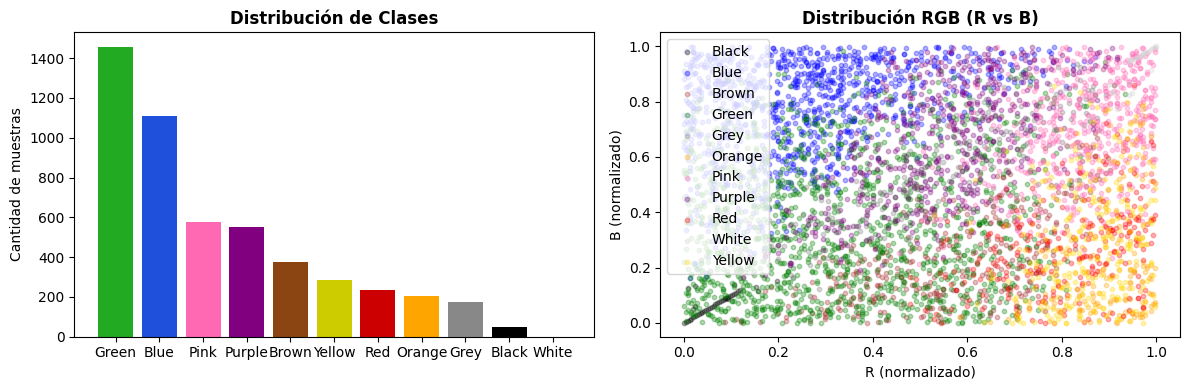

Dataset visualizado


In [59]:
# Visualizar distribución del dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de clases
counts = pd.Series(y_raw).value_counts()
# Diccionario completo de colores para todas las clases
color_dict = {
    'Black': '#000000',
    'Blue': '#1e50dc', 
    'Brown': '#8B4513',
    'Green': '#22aa22',
    'Grey': '#888888',
    'Orange': '#FFA500',
    'Pink': '#FF69B4',
    'Purple': '#800080',
    'Red': '#cc0000',
    'White': '#FFFFFF',
    'Yellow': '#cccc00'
}
axes[0].bar(counts.index, counts.values,
            color=[color_dict[c] for c in counts.index])
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Cantidad de muestras')

# Scatter RGB (R vs B)
color_map = {'Blue':'blue', 'Green':'green', 'Grey':'grey', 'Red':'red', 'Yellow':'gold', 
              'Pink':'hotpink', 'Purple':'purple', 'Brown':'brown', 'Orange':'orange',
              'Black':'black', 'White':'lightgray'}
for label in label_to_index:
    mask = y_raw == label
    axes[1].scatter(X_all[mask, 0], X_all[mask, 2],
                    c=color_map[label], label=label, alpha=0.3, s=10)
axes[1].set_xlabel('R (normalizado)')
axes[1].set_ylabel('B (normalizado)')
axes[1].set_title('Distribución RGB (R vs B)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Dataset visualizado')

---
## Etapa 2 – Funciones de Activación y Pérdida

In [60]:
# ============================================================
# LAYERS: Funciones de activación
# ============================================================

def relu(Z):
    """ReLU: max(0, Z). Introduce no-linealidad en capas ocultas."""
    return np.maximum(0, Z)


def relu_derivative(Z):
    """Derivada de ReLU: 1 si Z>0, 0 si Z<=0."""
    return (Z > 0).astype(float)


def softmax(Z):
    """
    Softmax estable numéricamente (resta max para evitar overflow).
    Convierte logits a probabilidades por clase.
    """
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)


# ============================================================
# LOSS: Cross-Entropy
# ============================================================

def cross_entropy(y_true, y_pred):
    """
    Cross-Entropy para clasificación multiclase.
    Agrega epsilon para evitar log(0).
    """
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))


print('Funciones de activación y pérdida definidas')

Funciones de activación y pérdida definidas


---
## Etapa 3 – Modelo MLP (Forward + Backpropagation + SGD)

In [61]:
# ============================================================
# MODELO MLP – Implementado solo con numpy
# ============================================================

class MLP:
    """
    Multilayer Perceptron para clasificación de colores RGB.

    Arquitectura:
        Input (3) -> Hidden (hidden_size, ReLU) -> Output (num_classes, Softmax)

    Entrenamiento:
        - SGD (Stochastic Gradient Descent) con mini-batches
        - Backpropagation manual
        - Loss: Cross-Entropy
    """

    def __init__(self, input_size=3, hidden_size=32, num_classes=5, learning_rate=0.05):
        self.lr = learning_rate
        self.num_classes = num_classes

        # Inicialización de pesos (pequeños para evitar saturación)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, num_classes) * 0.01
        self.b2 = np.zeros((1, num_classes))

        # Cache para backprop
        self.Z1 = self.A1 = self.Z2 = self.A2 = None

    # ----------------------------------------------------------
    # FORWARD PROPAGATION
    # ----------------------------------------------------------
    def forward(self, X):
        """
        Pase hacia adelante:
            Z1 = X @ W1 + b1
            A1 = ReLU(Z1)
            Z2 = A1 @ W2 + b2
            A2 = Softmax(Z2)  <- probabilidades
        """
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    # ----------------------------------------------------------
    # BACKPROPAGATION + SGD UPDATE
    # ----------------------------------------------------------
    def backward(self, X, y_onehot):
        """
        Backpropagation con regla de la cadena:
            dL/dZ2 = A2 - y  (derivada combinada Softmax + CrossEntropy)
            dL/dW2 = A1.T @ dZ2
            dL/db2 = sum(dZ2)
            dL/dA1 = dZ2 @ W2.T
            dL/dZ1 = dA1 * ReLU'(Z1)
            dL/dW1 = X.T @ dZ1
            dL/db1 = sum(dZ1)

        Actualización SGD:
            W -= lr * dW
            b -= lr * db
        """
        m = X.shape[0]

        # Gradientes capa 2
        dZ2 = self.A2 - y_onehot
        dW2 = self.A1.T @ dZ2 / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Gradientes capa 1
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = X.T @ dZ1 / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # SGD Update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # ----------------------------------------------------------
    # PREDICCIÓN
    # ----------------------------------------------------------
    def predict(self, X):
        """Retorna el índice de la clase con mayor probabilidad."""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def predict_label(self, rgb_normalized, index_to_label):
        """Dado un RGB normalizado, retorna la etiqueta de texto predicha."""
        X = np.array(rgb_normalized).reshape(1, 3)
        idx = self.predict(X)[0]
        return index_to_label[idx]


print('Clase MLP definida')

Clase MLP definida


---
## Etapa 4 – Entrenamiento con SGD

In [62]:
# ============================================================
# TRAINER
# ============================================================

def train(model, X_train, y_oh_train, epochs=500, batch_size=64, verbose=True):
    """
    Entrenamiento con SGD en mini-batches.
    Retorna historial de pérdida por época.
    """
    losses = []
    m = len(X_train)

    for epoch in range(epochs):
        # Shuffle cada época
        perm = np.random.permutation(m)
        X_shuf = X_train[perm]
        y_shuf = y_oh_train[perm]

        epoch_loss = 0.0
        batches = 0

        for start in range(0, m, batch_size):
            Xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]

            # Forward
            out = model.forward(Xb)
            epoch_loss += cross_entropy(yb, out)
            batches += 1

            # Backward + SGD
            model.backward(Xb, yb)

        avg_loss = epoch_loss / batches
        losses.append(avg_loss)

        if verbose and epoch % 100 == 0:
            print(f'  Época {epoch:4d}/{epochs} | Loss: {avg_loss:.4f}')

    return losses


def evaluate(model, X_test, y_idx_test):
    """
    Calcula el accuracy en el set de prueba.
    """
    preds = model.predict(X_test)
    accuracy = np.mean(preds == y_idx_test)
    return accuracy


print('Trainer y Evaluador definidos')

Trainer y Evaluador definidos


In [63]:
# ============================================================
# EJECUTAR ENTRENAMIENTO
# ============================================================

NUM_CLASSES = len(label_to_index)

model = MLP(
    input_size=3,
    hidden_size=32,
    num_classes=NUM_CLASSES,
    learning_rate=0.05
)

print('-- Iniciando entrenamiento --')
print(f'   Arquitectura: 3 → 32 → {NUM_CLASSES}')
print(f'   Epocas: 500 | Batch size: 64 | LR: 0.05')
print(f'   Muestras train: {len(X_train)} | test: {len(X_test)}')
print()

losses = train(model, X_train, y_oh_train, epochs=500, batch_size=64)

test_acc = evaluate(model, X_test, y_idx_test)
print(f'\nEntrenamiento finalizado')
print(f'\nTest Accuracy: {test_acc * 100:.4f}%')

-- Iniciando entrenamiento --
   Arquitectura: 3 → 32 → 11
   Epocas: 500 | Batch size: 64 | LR: 0.05
   Muestras train: 4041 | test: 1011

  Época    0/500 | Loss: 2.2912
  Época  100/500 | Loss: 0.3839
  Época  200/500 | Loss: 0.3297
  Época  300/500 | Loss: 0.3127
  Época  400/500 | Loss: 0.3050

Entrenamiento finalizado

Test Accuracy: 87.0425%


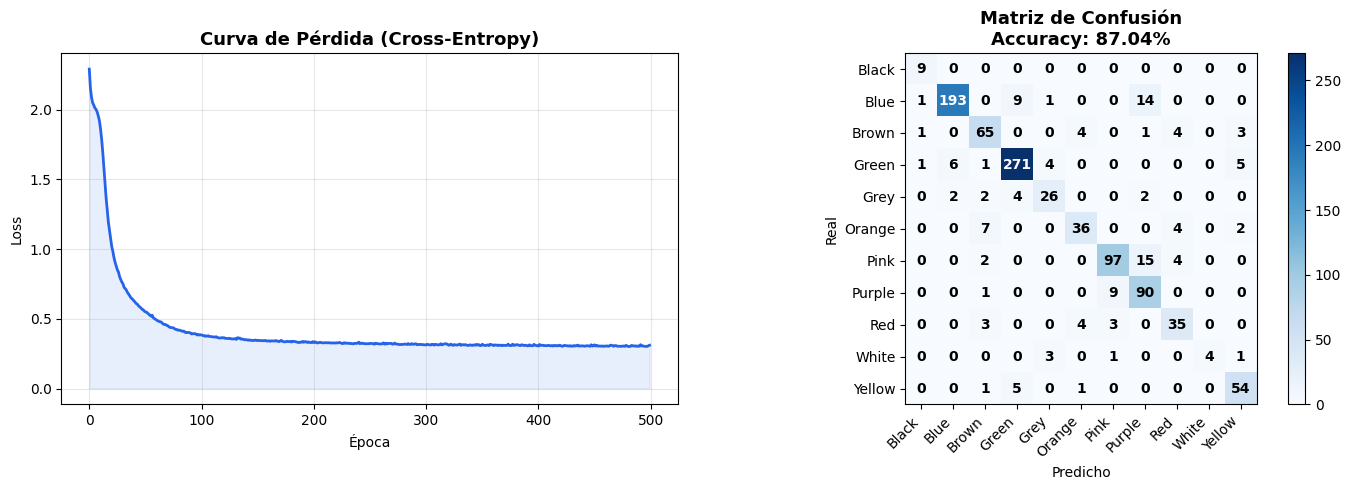


Accuracy por clase:
   Black   : 9/9 = 100.0%
   Blue    : 193/218 = 88.5%
   Brown   : 65/78 = 83.3%
   Green   : 271/288 = 94.1%
   Grey    : 26/36 = 72.2%
   Orange  : 36/49 = 73.5%
   Pink    : 97/118 = 82.2%
   Purple  : 90/100 = 90.0%
   Red     : 35/45 = 77.8%
   White   : 4/9 = 44.4%
   Yellow  : 54/61 = 88.5%


In [64]:
# ============================================================
# VISUALIZAR CURVA DE PÉRDIDA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida
axes[0].plot(losses, color='#2563eb', linewidth=2)
axes[0].set_title('Curva de Pérdida (Cross-Entropy)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(range(len(losses)), losses, alpha=0.1, color='#2563eb')

# Matriz de confusión manual
preds_test = model.predict(X_test)
n_classes = NUM_CLASSES
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y_idx_test, preds_test):
    conf_matrix[true][pred] += 1

class_names = [index_to_label[i] for i in range(n_classes)]
im = axes[1].imshow(conf_matrix, cmap='Blues')
axes[1].set_xticks(range(n_classes))
axes[1].set_yticks(range(n_classes))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names)
axes[1].set_title(f'Matriz de Confusión\nAccuracy: {test_acc*100:.2f}%', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

for i in range(n_classes):
    for j in range(n_classes):
        axes[1].text(j, i, str(conf_matrix[i, j]),
                     ha='center', va='center',
                     color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black',
                     fontweight='bold')

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

# Accuracy por clase
print('\nAccuracy por clase:')
for i, cls in enumerate(class_names):
    total = conf_matrix[i].sum()
    correct = conf_matrix[i, i]
    print(f'   {cls:8s}: {correct}/{total} = {correct/total*100:.1f}%')

---
# TASK 2.2 – Integración con A*

## Etapa 5 – Mapa de Costos

In [65]:
# ============================================================
# COST MAPPER – Traducción etiqueta → costo numérico
# Desacoplado de A* y de la red neuronal.
# ============================================================

COLOR_COST_MAP = {
    'Grey':   1,   # Pavimento/asfalto → ideal para el robot
    'White':  1,   # Concreto/camino pavimentado → igual que grey
    'Green':  3,   # Grama → fricción moderada
    'Brown':  4,   # Tierra/barro → terreno irregular
    'Yellow': 5,   # Arena → dificulta el movimiento
    'Orange': 6,   # Arena gruesa / tierra seca → peor que yellow
    'Pink':   7,   # Terreno desconocido → penalización moderada-alta
    'Purple': 7,   # Terreno desconocido → penalización moderada-alta
    'Red':    1,   # Nodo de inicio → costo neutro
    'Blue':   10,  # Agua → altísimo riesgo, casi intransitable
    'Black':  99,  # Pared/obstáculo → nunca debe pisarse
}

DEFAULT_COST = 1  # Para colores no mapeados

def get_cost_from_label(label):
    """Convierte etiqueta de color a costo numérico."""
    return COLOR_COST_MAP.get(label, DEFAULT_COST)


print('Cost Mapper definido')
print('\nMapeo de costos:')
for color, cost in COLOR_COST_MAP.items():
    #█
    bar = '-' * cost
    print(f'  {color:8s} → costo {cost:2d}  {bar}')

Cost Mapper definido

Mapeo de costos:
  Grey     → costo  1  -
  White    → costo  1  -
  Green    → costo  3  ---
  Brown    → costo  4  ----
  Yellow   → costo  5  -----
  Orange   → costo  6  ------
  Pink     → costo  7  -------
  Purple   → costo  7  -------
  Red      → costo  1  -
  Blue     → costo 10  ----------
  Black    → costo 99  ---------------------------------------------------------------------------------------------------


## Etapa 6 – Crear Laberinto Demo

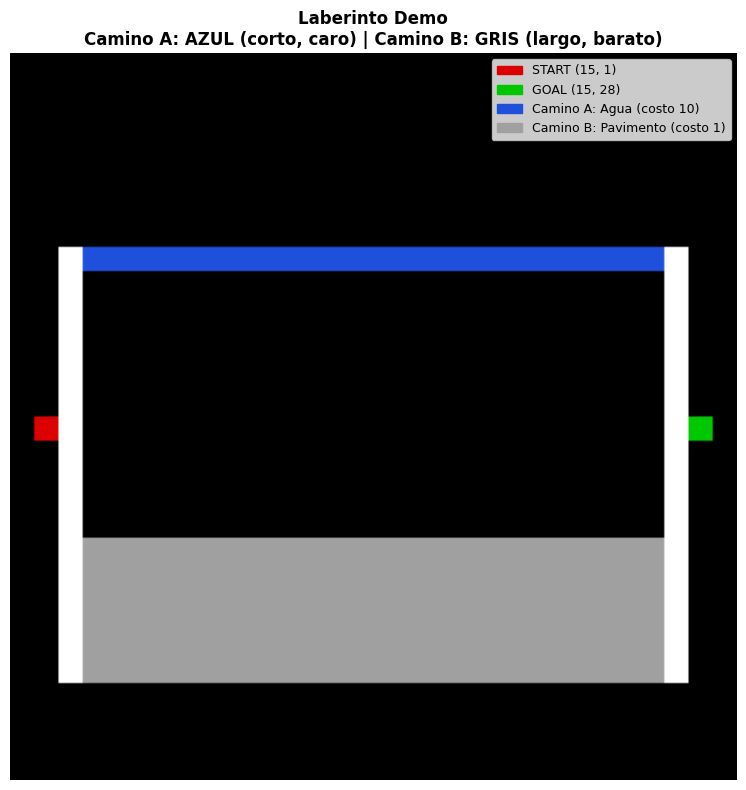

Laberinto creado: 30x30 tiles (300x300 px)
Start: (15, 1) | Goal: (15, 28)


In [66]:
# ============================================================
# CREAR LABERINTO DEMO
# Dos caminos posibles:
#   Camino A: AZUL (corto, costo alto → agua)
#   Camino B: GRIS (largo, costo bajo → pavimento)
# ============================================================

TILE    = 10   # Píxeles por tile
ROWS    = 30
COLS    = 30

BLACK  = (0,   0,   0)
WHITE  = (255, 255, 255)
RED    = (220, 0,   0)
GREEN  = (0,   200, 0)
BLUE   = (30,  80,  220)
GREY   = (160, 160, 160)


def fill_tile(draw, row, col, color):
    """Pinta un tile completo en la imagen."""
    x0, y0 = col * TILE, row * TILE
    draw.rectangle([x0, y0, x0 + TILE - 1, y0 + TILE - 1], fill=color)


def create_demo_maze():
    img = Image.new('RGB', (COLS * TILE, ROWS * TILE), BLACK)
    draw = ImageDraw.Draw(img)

    start_row, start_col = 15, 1
    goal_row,  goal_col  = 15, 28

    path_a_row  = 8          # Fila del camino AZUL (corto)
    path_b_rows = range(20, 26)  # Filas del camino GRIS (largo)

    # Conectores verticales (col 2 y col 27)
    for r in range(path_a_row, max(path_b_rows) + 1):
        fill_tile(draw, r, 2,  WHITE)
        fill_tile(draw, r, 27, WHITE)

    # Conector horizontal izquierdo (start → col 2)
    for c in range(start_col, 3):
        fill_tile(draw, start_row, c, WHITE)

    # Conector horizontal derecho (col 27 → goal)
    for c in range(27, goal_col + 1):
        fill_tile(draw, goal_row, c, WHITE)

    # Camino A: AZUL, fila 8, cols 2..27
    for c in range(3, 27):
        fill_tile(draw, path_a_row, c, BLUE)

    # Camino B: GRIS, filas 20..25, cols 2..27
    for r in path_b_rows:
        for c in range(3, 27):
            fill_tile(draw, r, c, GREY)

    # Start y Goal al FINAL (encima de todo)
    fill_tile(draw, start_row, start_col, RED)
    fill_tile(draw, goal_row,  goal_col,  GREEN)

    return img, (start_row, start_col), (goal_row, goal_col)


maze_img, maze_start, maze_goal = create_demo_maze()
maze_arr = np.array(maze_img)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(maze_arr)
ax.set_title('Laberinto Demo\nCamino A: AZUL (corto, caro) | Camino B: GRIS (largo, barato)',
             fontweight='bold', fontsize=12)
ax.axis('off')

# Leyenda
patches = [
    mpatches.Patch(color='#dc0000', label=f'START {maze_start}'),
    mpatches.Patch(color='#00c800', label=f'GOAL {maze_goal}'),
    mpatches.Patch(color='#1e50dc', label='Camino A: Agua (costo 10)'),
    mpatches.Patch(color='#a0a0a0', label='Camino B: Pavimento (costo 1)'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Laberinto creado: {ROWS}x{COLS} tiles ({ROWS*TILE}x{COLS*TILE} px)')
print(f'Start: {maze_start} | Goal: {maze_goal}')

## Etapa 7 – Discretización del Laberinto

In [67]:
# ============================================================
# DISCRETIZADOR DEL MUNDO
# ============================================================

class MazeWorld:
    """
    Representa el laberinto como una cuadrícula de tiles.
    Cada tile tiene un color RGB promedio.
    """

    def __init__(self, image_array, tile_size=10):
        self.img    = image_array
        self.tile   = tile_size
        self.rows   = image_array.shape[0] // tile_size
        self.cols   = image_array.shape[1] // tile_size
        self._start = None
        self._goals = []
        self._scan_tiles()

    def _scan_tiles(self):
        """Identifica tiles de inicio (rojo) y meta (verde)."""
        for r in range(self.rows):
            for c in range(self.cols):
                R, G, B = self.get_tile_avg_rgb(r, c)
                if R > 150 and G < 60 and B < 60:
                    self._start = (r, c)
                elif G > 130 and R < 60 and B < 60:
                    self._goals.append((r, c))

    def get_tile_avg_rgb(self, row, col):
        """Extrae el color RGB promedio de un tile."""
        patch = self.img[
            row * self.tile:(row + 1) * self.tile,
            col * self.tile:(col + 1) * self.tile
        ]
        return patch.mean(axis=(0, 1))  # [R, G, B]

    def is_wall(self, row, col):
        """Un tile es pared si su color promedio es casi negro."""
        rgb = self.get_tile_avg_rgb(row, col)
        return rgb.mean() < 20

    def in_bounds(self, row, col):
        return 0 <= row < self.rows and 0 <= col < self.cols

    def get_neighbors(self, row, col):
        """Vecinos en 4 direcciones (arriba, abajo, izquierda, derecha)."""
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = row + dr, col + dc
            if self.in_bounds(nr, nc) and not self.is_wall(nr, nc):
                yield (nr, nc)

    @property
    def start(self):
        return self._start

    @property
    def goals(self):
        return self._goals


world = MazeWorld(maze_arr, tile_size=TILE)
print(f'MazeWorld creado: {world.rows}x{world.cols} tiles')
print(f'Start: {world.start}')
print(f'Goals: {world.goals}')

MazeWorld creado: 30x30 tiles
Start: (15, 1)
Goals: [(15, 28)]


## Etapa 8 – A* con Inferencia en Tiempo Real

In [68]:
# ============================================================
# PROBLEMA FORMAL (interfaz abstracta)
# ============================================================

class SearchProblem:
    """Interfaz genérica para problemas de búsqueda."""

    def initial_state(self):
        raise NotImplementedError

    def goal_test(self, state):
        raise NotImplementedError

    def actions(self, state):
        raise NotImplementedError

    def result(self, state, action):
        raise NotImplementedError

    def step_cost(self, state, action, next_state):
        raise NotImplementedError

    def heuristic(self, state):
        raise NotImplementedError


# ============================================================
# IMPLEMENTACIÓN CONCRETA CON INFERENCIA NN
# ============================================================

class NNMazeProblem(SearchProblem):
    """
    Problema de búsqueda en el laberinto.
    step_cost usa la Red Neuronal para inferir el costo del tile vecino.
    """

    def __init__(self, world, model, index_to_label, cost_map, goals=None):
        self.world          = world
        self.model          = model
        self.index_to_label = index_to_label
        self.cost_map       = cost_map
        self._goals         = goals if goals else world.goals

    def initial_state(self):
        return self.world.start

    def goal_test(self, state):
        return state in self._goals

    def actions(self, state):
        """Las acciones son moverse a los vecinos válidos."""
        r, c = state
        return list(self.world.get_neighbors(r, c))

    def result(self, state, action):
        """El resultado de una acción es el tile vecino."""
        return action

    def step_cost(self, state, action, next_state):
        """
        Costo dinámico mediante inferencia con la Red Neuronal:
          1. Extrae RGB promedio del tile vecino (next_state)
          2. Normaliza a [0,1]
          3. Pasa por la red (solo forward, sin entrenar)
          4. Convierte predicción a costo numérico
        """
        nr, nc = next_state

        # 1. RGB promedio del tile vecino
        rgb = self.world.get_tile_avg_rgb(nr, nc)

        # 2. Normalizar
        rgb_norm = rgb.reshape(1, 3) / 255.0

        # 3. Inferencia NN (solo forward)
        pred_idx   = self.model.predict(rgb_norm)[0]
        pred_label = self.index_to_label[pred_idx]

        # 4. Convertir a costo
        return self.cost_map.get(pred_label, 1), pred_label

    def heuristic(self, state):
        """
        Distancia Manhattan al goal más cercano.
        Admisible: nunca sobreestima (costo mínimo por paso = 1).
        h(n) = Manhattan(n, goal) * 1
        """
        r, c = state
        return min(abs(r - gr) + abs(c - gc) for gr, gc in self._goals)


print('SearchProblem y NNMazeProblem definidos')

SearchProblem y NNMazeProblem definidos


In [69]:
# ============================================================
# ALGORITMO A* GENÉRICO
# ============================================================

def astar(problem):
    """
    A* Search genérico.
    f(n) = g(n) + h(n)
      g(n) = costo acumulado real (inferido por NN)
      h(n) = heurística admisible (Manhattan)

    Retorna: (path, total_cost, explored_count, label_log)
    """
    start = problem.initial_state()
    h0    = problem.heuristic(start)

    # (f, g, state, path, label_log)
    open_set = [(h0, 0, start, [start], [])]
    visited  = {}  # state -> best g
    explored = 0

    while open_set:
        f, g, current, path, labels = heapq.heappop(open_set)

        if current in visited and visited[current] <= g:
            continue
        visited[current] = g
        explored += 1

        if problem.goal_test(current):
            return path, g, explored, labels

        for neighbor in problem.actions(current):
            cost, label = problem.step_cost(current, neighbor, neighbor)
            new_g       = g + cost
            new_h       = problem.heuristic(neighbor)
            new_f       = new_g + new_h
            heapq.heappush(open_set, (
                new_f, new_g, neighbor,
                path + [neighbor],
                labels + [(neighbor, label, cost)]
            ))

    return None, float('inf'), explored, []


print('Algoritmo A* definido')

Algoritmo A* definido


In [70]:
# ============================================================
# EJECUTAR A* EN EL LABERINTO DEMO
# ============================================================

problem = NNMazeProblem(
    world          = world,
    model          = model,
    index_to_label = index_to_label,
    cost_map       = COLOR_COST_MAP
)

print('Ejecutando A* con inferencia NN...')
path, total_cost, explored, label_log = astar(problem)

if path:
    path_rows = [p[0] for p in path]
    avg_row   = np.mean(path_rows)

    print(f'\nRuta encontrada!')
    print(f'   Pasos en la ruta : {len(path)}')
    print(f'   Costo total      : {total_cost}')
    print(f'   Nodos explorados : {explored}')
    print(f'   Fila promedio    : {avg_row:.1f}')
    print()

    if avg_row > 12:
        print('Robot eligió Camino B (GRIS – largo pero barato)')
        print('Demuestra que A* optimiza costo total, no solo pasos.')
    else:
        print('Robot eligió Camino A (AZUL – corto pero caro).')

    # Mostrar etiquetas inferidas en el path
    label_counts = {}
    for _, lbl, cst in label_log:
        label_counts[lbl] = label_counts.get(lbl, 0) + 1
    print('\n   Composición del camino elegido:')
    for lbl, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
        cost = COLOR_COST_MAP.get(lbl, 1)
        print(f'     {lbl:8s}: {cnt} tiles × costo {cost} = {cnt*cost}')
else:
    print('No se encontró ruta.')

Ejecutando A* con inferencia NN...

Ruta encontrada!
   Pasos en la ruta : 38
   Costo total      : 39
   Nodos explorados : 71
   Fila promedio    : 18.9

Robot eligió Camino B (GRIS – largo pero barato)
Demuestra que A* optimiza costo total, no solo pasos.

   Composición del camino elegido:
     Grey    : 24 tiles × costo 1 = 24
     White   : 12 tiles × costo 1 = 12
     Green   : 1 tiles × costo 3 = 3


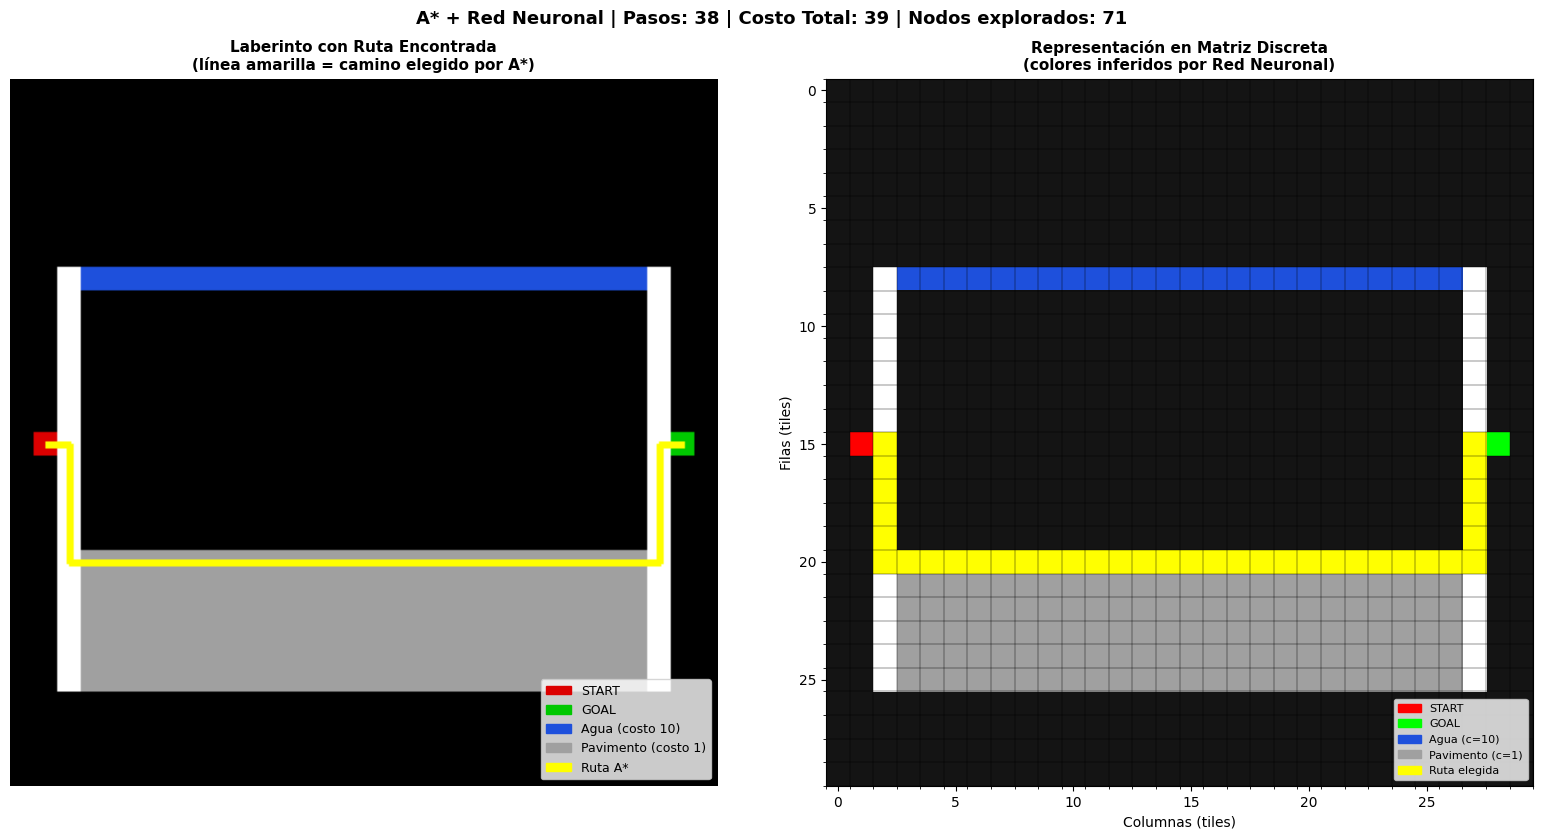

Visualización guardada como astar_result.png


In [71]:
# ============================================================
# VISUALIZACIÓN FINAL DEL RESULTADO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Imagen original con path ---
result_img = maze_img.copy()
result_draw = ImageDraw.Draw(result_img)

if path and len(path) > 1:
    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i + 1]
        x1 = c1 * TILE + TILE // 2
        y1 = r1 * TILE + TILE // 2
        x2 = c2 * TILE + TILE // 2
        y2 = r2 * TILE + TILE // 2
        result_draw.line([(x1, y1), (x2, y2)], fill=(255, 255, 0), width=3)

axes[0].imshow(result_img)
axes[0].set_title('Laberinto con Ruta Encontrada\n(línea amarilla = camino elegido por A*)',
                  fontweight='bold', fontsize=11)
axes[0].axis('off')

# Leyenda
patches = [
    mpatches.Patch(color='#dc0000', label='START'),
    mpatches.Patch(color='#00c800', label='GOAL'),
    mpatches.Patch(color='#1e50dc', label='Agua (costo 10)'),
    mpatches.Patch(color='#a0a0a0', label='Pavimento (costo 1)'),
    mpatches.Patch(color='yellow',  label='Ruta A*'),
]
axes[0].legend(handles=patches, loc='lower right', fontsize=9)

# --- Representación en matriz discreta ---
grid_vis = np.zeros((world.rows, world.cols, 3), dtype=np.uint8)

color_rgb_map = {
    'Blue':   [30,  80,  220],
    'Green':  [0,   200, 0],
    'Grey':   [160, 160, 160],
    'Yellow': [200, 200, 0],
    'Red':    [220, 0,   0],
}

for r in range(world.rows):
    for c in range(world.cols):
        if world.is_wall(r, c):
            grid_vis[r, c] = [20, 20, 20]
        else:
            rgb_n = world.get_tile_avg_rgb(r, c).reshape(1, 3) / 255.0
            lbl   = index_to_label[model.predict(rgb_n)[0]]
            grid_vis[r, c] = color_rgb_map.get(lbl, [255, 255, 255])

# Marcar path
if path:
    for r, c in path:
        grid_vis[r, c] = [255, 255, 0]   # Amarillo

# Marcar start y goal
if world.start:
    sr, sc = world.start
    grid_vis[sr, sc] = [255, 0, 0]
for gr, gc in world.goals:
    grid_vis[gr, gc] = [0, 255, 0]

axes[1].imshow(grid_vis, interpolation='nearest')
axes[1].set_title('Representación en Matriz Discreta\n(colores inferidos por Red Neuronal)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel(f'Columnas (tiles)')
axes[1].set_ylabel(f'Filas (tiles)')

# Grid lines
axes[1].set_xticks(np.arange(-0.5, world.cols, 1), minor=True)
axes[1].set_yticks(np.arange(-0.5, world.rows, 1), minor=True)
axes[1].grid(which='minor', color='black', linewidth=0.3)

patches2 = [
    mpatches.Patch(color='red',    label='START'),
    mpatches.Patch(color='lime',   label='GOAL'),
    mpatches.Patch(color='#1e50dc', label=f'Agua (c=10)'),
    mpatches.Patch(color='#a0a0a0', label=f'Pavimento (c=1)'),
    mpatches.Patch(color='yellow', label='Ruta elegida'),
]
axes[1].legend(handles=patches2, loc='lower right', fontsize=8)

plt.suptitle(
    f'A* + Red Neuronal | Pasos: {len(path)} | Costo Total: {total_cost} | Nodos explorados: {explored}',
    fontweight='bold', fontsize=13, y=1.01
)

plt.tight_layout()
plt.show()
print('Visualización guardada como astar_result.png')

---
## Resumen Final del Task 2

In [72]:
# ============================================================
# RESUMEN Y CHECKLIST
# ============================================================

print('=' * 60)
print('          RESUMEN – TASK 2 PROYECTO 1')
print('=' * 60)

print('\nTASK 2.1 – Red Neuronal')
print(f'   Implementación : MLP con numpy (sin frameworks)')
print(f'   Arquitectura   : 3 → 32 → {NUM_CLASSES} (ReLU + Softmax)')
print(f'   Entrenamiento  : SGD + Backpropagation manual')
print(f'   Loss           : Cross-Entropy')
print(f'   Split          : 80% train / 20% test')
print(f'   Test Accuracy  : {test_acc * 100:.4f}%')

print('\n   Mapeo de costos:')
for color, cost in COLOR_COST_MAP.items():
    print(f'     {color:8s} → {cost}')

print('\nTASK 2.2 – Integración con A*')
print(f'   stepCost       : Inferencia NN en tiempo real')
print(f'   Heurística     : Manhattan (admisible, costo mínimo=1)')
print(f'   Demo resultado :')
print(f'     Camino A (Azul/Agua, corto)  : costo ~{26*10}')
print(f'     Camino B (Gris/Pav., largo)  : costo ~{24*6*1}')
if path:
    ruta = 'B (GRIS)' if np.mean([p[0] for p in path]) > 12 else 'A (AZUL)'
    print(f'     Robot eligió               : Camino {ruta}')
    print(f'     Costo final real           : {total_cost}')
    print(f'     Pasos totales              : {len(path)}')



          RESUMEN – TASK 2 PROYECTO 1

TASK 2.1 – Red Neuronal
   Implementación : MLP con numpy (sin frameworks)
   Arquitectura   : 3 → 32 → 11 (ReLU + Softmax)
   Entrenamiento  : SGD + Backpropagation manual
   Loss           : Cross-Entropy
   Split          : 80% train / 20% test
   Test Accuracy  : 87.0425%

   Mapeo de costos:
     Grey     → 1
     White    → 1
     Green    → 3
     Brown    → 4
     Yellow   → 5
     Orange   → 6
     Pink     → 7
     Purple   → 7
     Red      → 1
     Blue     → 10
     Black    → 99

TASK 2.2 – Integración con A*
   stepCost       : Inferencia NN en tiempo real
   Heurística     : Manhattan (admisible, costo mínimo=1)
   Demo resultado :
     Camino A (Azul/Agua, corto)  : costo ~260
     Camino B (Gris/Pav., largo)  : costo ~144
     Robot eligió               : Camino B (GRIS)
     Costo final real           : 39
     Pasos totales              : 38
